# Online Stochastic Matchings: Stability on Hypergraphs

This is the companion notebook of the paper *Online Stochastic Matchings: Stability on Hypergraphs*.

It covers the numerical claims of the paper, focusing on the candy hypergraph:

1. **The characterization of stability.** `model.stabilizable` decides any $(G,\lambda)$; `model.maximin`
   gives the witness flow $\mu$; `model.incidence` gives the matrix.
2. **The candy's closed-form stability region**, checked against `model.stabilizable`.
3. **Regular greedy ML vs. VQML** on the candy $\alpha$-family (the paper's figure).
4. **The provable greedy-instability threshold** $\alpha<2/21$: the domination and
   throughput-conservation ingredients.
5. **Accessibility and tie-breaking of the virtual chain**: proof-level combinatorics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import multiprocess as mp
import stochastic_matching as sm
from stochastic_matching import XP, Iterator, evaluate

print("stochastic_matching:", sm.__version__)
np.set_printoptions(precision=4, suppress=True)

stochastic_matching: 0.4.0


First, recall the candy structure: two triangles bridged by a hyperedge that includes a seventh node:

In [6]:
candy = sm.HyperPaddle()
print("candy incidence A (from model.incidence):")
print(np.asarray(candy.incidence), "\n")
candy.show_graph()

candy incidence A (from model.incidence):
[[1 1 0 0 0 0 0]
 [1 0 1 0 0 0 0]
 [0 1 1 0 0 0 1]
 [0 0 0 0 0 0 1]
 [0 0 0 1 1 0 1]
 [0 0 0 1 0 1 0]
 [0 0 0 0 1 1 0]] 



## Characterization of stability

The package decides stabilizability directly: `model.stabilizable` is `True` iff the maximin
conservation flow is strictly positive **and** the incidence matrix is surjective, i.e.
conditions (iii)/(iv) of the main theorem. When stabilizable, `model.maximin` *is* a positive
witness $\mu$ with $A\mu=\lambda$; when not, either the flow has a non-positive coordinate
(the cone is left) or $A$ is rank-deficient.

> Note: The dual *certificate* $y$ of condition (ii) is stated in the paper; the package works directly with the primal witness.

We will use the `report` function to observe a few cases.

In [7]:
def report(name, model):
    A = np.asarray(model.incidence)
    mu = np.asarray(model.maximin)
    rank, n = np.linalg.matrix_rank(A), A.shape[0]
    print(f"{name}")
    print(f"  stabilizable = {model.stabilizable}   "
          f"(rank A = {rank} of {n}; maximin min = {mu.min():.3f})")
    print(f"  maximin flow mu = {mu.round(4)}")

In [10]:
candy.rates = [1, 1, 0.9, 0.3, 0.9, 1, 1]
report("candy, alpha-family (alpha=0.3): lambda=(1,1,3a,a,3a,1,1)", candy)
candy.show_flow()

candy, alpha-family (alpha=0.3): lambda=(1,1,3a,a,3a,1,1)
  stabilizable = True   (rank A = 7 of 7; maximin min = 0.300)
  maximin flow mu = [0.7 0.3 0.3 0.3 0.3 0.7 0.3]


In [15]:
candy.rates = [1, 1, 1, 5, 1, 1, 1]
report("candy, center overloaded λ_4=5", candy)
candy.show_flow()

candy, center overloaded λ_4=5
  stabilizable = False   (rank A = 7 of 7; maximin min = -2.000)
  maximin flow mu = [ 3. -2. -2. -2. -2.  3.  5.]


In [17]:
model = sm.Model(incidence=[[0, 1, 1, 0], [0, 0, 1, 1], [1, 1, 1, 1]], rates=[1, 1, 2]) 
report("rem:wall degenerate (stabilizable; every basic solution degenerate)", model)
model.show_kernel(disp_flow=True)

rem:wall degenerate (stabilizable; every basic solution degenerate)
  stabilizable = True   (rank A = 3 of 3; maximin min = 0.500)
  maximin flow mu = [0.5 0.5 0.5 0.5]


In [19]:
model = sm.Model(incidence=[[1], [1], [1]], rates=[1, 1, 1])
report("Moyal single 3-hyperedge {1,2,3} (rank 1 < 3)", model)
model.show_kernel(disp_flow=True)

Moyal single 3-hyperedge {1,2,3} (rank 1 < 3)
  stabilizable = False   (rank A = 1 of 3; maximin min = 1.000)
  maximin flow mu = [1.]


In [21]:
model = sm.Model(incidence=[[1, 0], [1, 0], [1, 1], [0, 1]], rates=[1, 1, 2, 1])
report("Moyal RM21 Prop-4 flavor: {1,2,3}+{3,4}, classes 1,2 degree one", model)
model.show_kernel(disp_flow=True)

Moyal RM21 Prop-4 flavor: {1,2,3}+{3,4}, classes 1,2 degree one
  stabilizable = False   (rank A = 2 of 4; maximin min = 1.000)
  maximin flow mu = [1. 1.]


## The candy's closed-form stability region

For the candy $A$ is square and invertible, so stabilizability $\iff$ the unique solution of
$A\mu=\lambda$ is strictly positive, which solves to
$$|\lambda_1-\lambda_2| < \lambda_3-\lambda_4 < \lambda_1+\lambda_2 \quad\text{and}\quad
  |\lambda_7-\lambda_6| < \lambda_5-\lambda_4 < \lambda_6+\lambda_7.$$

Recipe for the formula above:
- The 3-edge must be $\lambda_4$, leaving $\bar{\lambda_3}=\lambda_3-\lambda_4$ and $\bar{\lambda_5}=\lambda_5-\lambda_4$ for nodes 3 and 5.
- That leaves the triangles $\lambda_1$, $\lambda_2$, $\bar{\lambda_3}$, and $\lambda_6$, $\lambda_7$, $\bar{\lambda_5}$, which must uphold the triangular inequality.
- Triangular inequality for $a$, $b$, $c$: $|b-c|<a<b+c$.
  
One can check this closed form against `model.stabilizable` on random
rate vectors.

In [22]:
def candy_closed_form(lam):
    l1, l2, l3, l4, l5, l6, l7 = lam
    return (abs(l1 - l2) < l3 - l4 < l1 + l2) and (abs(l7 - l6) < l5 - l4 < l6 + l7)

rng = np.random.default_rng(0)
mism = 0
for _ in range(20000):
    lam = rng.uniform(0.2, 3.0, size=7)
    if candy_closed_form(lam) != sm.HyperPaddle(rates=list(lam)).stabilizable:
        mism += 1
print(f"closed form vs model.stabilizable over 20000 random rate vectors: {mism} mismatches")

closed form vs model.stabilizable over 20000 random rate vectors: 0 mismatches


## Greedy Match-the-longest (ML) vs. VQML on the candy $\alpha$-family

$\lambda^{(\alpha)}=(1,1,3\alpha,\alpha,3\alpha,1,1)$ is stabilizable for every
$\alpha\in(0,1)$, with the five *inner* edges having rate $\alpha$ and the two outer edges having rate $1-\alpha$.

Note that the extremal values, 0 and 1, yield an unstable problem (the support of the unique solution is not surjective).

Greedy match-the-longest lets the central queue explode for $\alpha < \alpha_0$, while VQML stays stable in $(0, 1)$.

Step #1: estimate $\alpha_0$

In [23]:
steps_done = 10_000_000
common = {'n_steps': steps_done, 'seed': 12, 'max_queue': 10_000}

def candy_at(alpha):
    return sm.HyperPaddle(rates=[1.0, 1.0, 3 * alpha, alpha, 3 * alpha, 1.0, 1.0])

In [24]:
αmin = 0.0
αmax = 1.0
ϵ = .001
with mp.Pool() as pool:
    span = pool._processes
    while αmax - αmin > ϵ:
        alphas = [αmin + (αmax - αmin)*i/(span+1) for i in range(1, span+1)]
        xp = XP('ML', simulator='longest', 
                iterator=Iterator('model', alphas, name='alpha', process=candy_at), **common)
        res = evaluate(xp, ['steps_done'], pool)
        if res['ML']['steps_done'][0] == steps_done:
            αmax = alphas[0]
        else:
            for i in range(1, span):
                if res['ML']['steps_done'][i] == steps_done:
                    αmin, αmax = alphas[i-1], alphas[i]
                    break
            else:
                αmin = alphas[-1]
    α0 = (αmin+αmax)/2
α0

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

0.4456543863220029

We then sweep $\alpha$.

We plot two metrics side by side: the mean central queue $\overline{Q_4}$ (the coordinate the
instability proof bounds, and the paper's figure) and the package's built-in `delay` (mean
waiting time by Little's law, $\sum_i\overline{Q_i}/\Lambda$). 

Both show the same thing on the left: greedy blows up as $\alpha\to \alpha_0$ while VQML goes to 0, so the separation does not hinge on singling out node~4. 

At large $\alpha$, delay and $\overline{Q_4}$ differ (the instability comes from outer nodes).

Also note that for delay and large $\alpha$, the curves cross: VQML carries slightly more global delay than
greedy. It is understandable, since VQML is a maximally *stable* witness through a reservation mechanism, not a delay optimizer.

In [25]:
# Metrics run in pool workers (shipped by value via dill), so keep them
# self-contained: no module globals. Node 4 = 0-based index 3.
def central_queue(simu):
    return float(simu.avg_queues[3])

alphas = [i/100 for i in range(1, 100)]
alphas2 = [i/100 for i in range(int(α0*100)+1, 100)]


xp = XP('ML', simulator='longest',
        iterator=Iterator('model', alphas2, name='alpha', process=candy_at), **common)
xp += XP('VQML', simulator='virtual_queue',
         iterator=Iterator('model', alphas, name='alpha', process=candy_at), **common)

with mp.Pool() as pool:
    res = evaluate(xp, ['steps_done', central_queue, 'delay'], pool)

  0%|          | 0/154 [00:00<?, ?it/s]

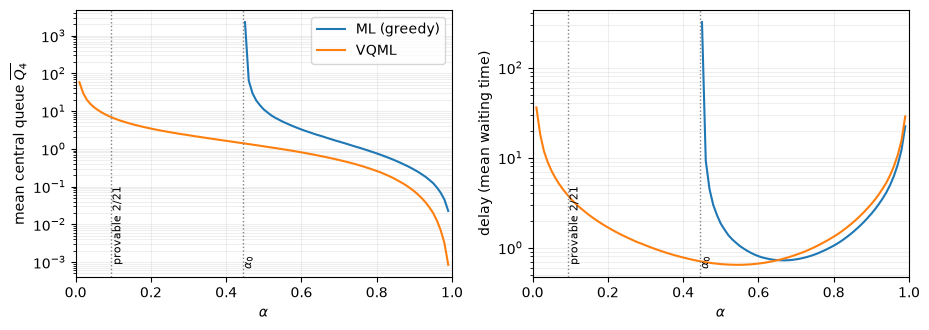

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.4), sharex=True)
panels = [('central_queue', r'mean central queue $\overline{Q_4}$'),
          ('delay', r'delay (mean waiting time)')]


for ax, (key, ylabel) in zip(axes, panels):
    # yml, yvq = np.array(ml[key]), np.array(vq[key])
    ax.semilogy(res['ML']['alpha'], res['ML'][key], ms=4, label='ML (greedy)')
    ax.semilogy(res['VQML']['alpha'], res['VQML'][key], ms=5, label='VQML')
    ax.axvline(2 / 21, color='gray', ls=':', lw=1)
    ax.text(2 / 21, 0.03, ' provable 2/21', rotation=90, va='bottom', fontsize=8,
            transform=ax.get_xaxis_transform())
    ax.axvline(α0, color='gray', ls=':', lw=1)
    ax.text(α0, 0.03, '$\\alpha_0$', rotation=90, va='bottom', fontsize=8,
            transform=ax.get_xaxis_transform())
    ax.set_xlabel(r'$\alpha$'); ax.set_ylabel(ylabel)
    ax.set_xlim(0, 1); ax.grid(True, which='both', alpha=0.2)
axes[0].legend()
plt.tight_layout(); plt.show()

## The provable greedy-instability threshold $\alpha<2/21$

For $\alpha<2/21\approx0.095$ **no** greedy policy is stable. The proof combines a
triangle/hyperedge invariant, an $M/M/1$ domination giving $\Pr(Q_3>0)\le 3\alpha/2$, and the
throughput identity $r_h=\lambda_4$. We corroborate the two ingredients where ML is stable
($\alpha\ge0.5$).

In [27]:
# Self-contained metrics (run in pool workers). Bridge = node 3 (0-based 2),
# hyperedge {3,4,5} = edge index 6.
def p_bridge(simu):                      # P(Q_bridge > 0) by PASTA
    return 1.0 - simu.logs.queue_log[2, 0] / simu.logs.steps_done

def rate_h_time(simu):                   # hyperedge firings per unit time
    return float(simu.logs.traffic[6] / simu.logs.steps_done * sum(simu.model.rates))

xp4 = XP('greedy', simulator='longest', model=None, n_steps=1_000_000, seed=1, max_queue=4000,
         iterator=Iterator('model', [0.5, 0.6, 0.7, 0.8], name='alpha', process=candy_at))
with mp.Pool() as pool:
    r4 = evaluate(xp4, [p_bridge, rate_h_time], pool)['greedy']

for a, pb, rh in zip(r4['alpha'], r4['p_bridge'], r4['rate_h_time']):
    print(f"alpha={a:.2f}: P(Qbridge>0)={pb:.3f} <= 3a/2={1.5*a:.3f}? {pb <= 1.5*a + 1e-3};  "
          f"rate(h)={rh:.4f} vs lambda_4={a:.4f}  (conservation)")
print("\nProvable threshold 2/21 =", round(2 / 21, 4), "; simulated ML threshold ~0.45.")

  0%|          | 0/4 [00:00<?, ?it/s]

alpha=0.50: P(Qbridge>0)=0.220 <= 3a/2=0.750? True;  rate(h)=0.4960 vs lambda_4=0.5000  (conservation)
alpha=0.60: P(Qbridge>0)=0.345 <= 3a/2=0.900? True;  rate(h)=0.5949 vs lambda_4=0.6000  (conservation)
alpha=0.70: P(Qbridge>0)=0.489 <= 3a/2=1.050? True;  rate(h)=0.6947 vs lambda_4=0.7000  (conservation)
alpha=0.80: P(Qbridge>0)=0.651 <= 3a/2=1.200? True;  rate(h)=0.7928 vs lambda_4=0.8000  (conservation)

Provable threshold 2/21 = 0.0952 ; simulated ML threshold ~0.45.


## Accessibility and tie-breaking of the virtual chain

Two structural facts about the signed virtual queue $Q$. These are *proof-level* combinatorics
(a custom adversarial tie-break rule, and a deterministic steering word) that the package's
`virtual_queue` simulator does not expose as knobs, so we check them directly with numpy.

**(a) The $I_2$ trap (tie-breaking remark).** Take $A=I_2$ (two mono-edges), $\lambda=(1,1)$,
and a legal *deterministic* maximizer rule that violates the idle clause (among maximizers,
prefer $2e_1, e_1, 2e_2, 0, e_2, e_1+e_2$). The set reachable from $0$ then has **9** states,
with $0$ visited exactly once and a **7**-state absorbing class. So the idle clause is what the
accessibility argument needs.

**(b) Steering to $0$ (accessibility lemma).** Under the canonical idle clause, the Appendix-A
steering drives $Q$ to $0$ from every state within $\lVert q\rVert_1 + 2 a_{\max} V(q)$. We run
it from many mixed-sign start states over a suite of incidence matrices (from the package where
available).

In [28]:
import itertools

# (a) adversarial I2 tie-break trap
A_I2 = np.eye(2, dtype=int)
feas = [s for s in itertools.product(range(3), repeat=2) if sum(s) <= 2]
pref = [(2, 0), (1, 0), (0, 2), (0, 0), (0, 1), (1, 1)]   # most preferred maximizer first

def i2_rule(q):
    scores = {s: int(np.array(q) @ (A_I2 @ np.array(s))) for s in feas}
    best = max(scores.values())
    cand = [s for s in feas if scores[s] == best]
    return next(s for s in pref if s in cand)

start = (0, 0); seen = {start}; frontier = [start]; edges = {}
while frontier:
    q = frontier.pop(); s = np.array(i2_rule(q)); succ = set()
    for a in ([1, 0], [0, 1]):
        qp = tuple(np.array(q) + np.array(a) - (A_I2 @ s)); succ.add(qp)
        if qp not in seen: seen.add(qp); frontier.append(qp)
    edges[q] = succ

def freach(src):
    acc = {src}; st = [src]
    while st:
        for v in edges.get(st.pop(), ()):
            if v not in acc: acc.add(v); st.append(v)
    return acc

reach = {u: freach(u) for u in seen}
sccs = []; done = set()
for u in seen:
    if u in done: continue
    comp = {v for v in seen if v in reach[u] and u in reach[v]}
    sccs.append(comp); done |= comp
bottom = sorted(len(c) for c in sccs if all(edges[u] <= c for u in c))
reenter = start in {v for x in edges[start] for v in reach[x]}
print(f"(a) I2 trap: reachable from 0 = {len(seen)} (paper 9); "
      f"0 re-enterable = {reenter} (paper False); absorbing SCC sizes = {bottom} (paper [7])")

# (b) steering to 0 under the canonical idle clause
def steer_to_zero(A, q0):
    A = np.asarray(A, int); n, m = A.shape
    a_max = max(int(A[:, k].sum()) for k in range(m))
    q = np.array(q0, int)
    bound = int(np.abs(q).sum()) + 2 * a_max * int(np.maximum(q, 0).sum())
    steps = 0
    while np.any(q != 0):
        if steps > bound: return False, steps, bound
        scores = A.T @ q
        if scores.max() <= 0:                                  # idle: drain a negative coord
            q = q + np.eye(n, dtype=int)[int(np.argmin(q))]
        else:                                                  # active: s = 2 e_kstar
            r = q - 2 * A[:, int(np.argmax(scores))]
            neg = np.where(r <= -1)[0]
            q = r + np.eye(n, dtype=int)[int(neg[0]) if neg.size else 0]
        steps += 1
    return True, steps, bound

suite = {
    "I2": A_I2,
    "candy": np.asarray(sm.HyperPaddle(rates=[1, 1, 1, 1, 1, 1, 1]).incidence),   # incidence from package
    "rem:wall": np.array([[0, 1, 1, 0], [0, 0, 1, 1], [1, 1, 1, 1]]),
    "Moyal {1,2,3}": np.array([[1], [1], [1]]),
    "Moyal {1,2,3}+{3,4}": np.array([[1, 0], [1, 0], [1, 1], [0, 1]]),
}
rng2 = np.random.default_rng(0); total = good = 0
for name, A in suite.items():
    for _ in range(200):
        reached, steps, bound = steer_to_zero(A, rng2.integers(-4, 6, size=A.shape[0]))
        total += 1; good += int(reached and steps <= bound)
print(f"(b) steering: {good}/{total} start states over the suite reach 0 within the bound")

(a) I2 trap: reachable from 0 = 9 (paper 9); 0 re-enterable = False (paper False); absorbing SCC sizes = [7] (paper [7])
(b) steering: 1000/1000 start states over the suite reach 0 within the bound
